<a href="https://www.kaggle.com/code/lalit7881/ai-workforce-shift-2020-26-eda-99?scriptVersionId=318314627" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/alitaqishah/ai-workforce-displacement-20202026/ai_workforce_displacement_global_2020_2026.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/alitaqishah/ai-workforce-displacement-20202026/ai_workforce_displacement_global_2020_2026.csv")

In [3]:
df.head()

,record_id,country,iso3_code,region,income_group,year,quarter,quarter_label,industry_sector,sector_automation_risk_score,...,pct_sector_workforce_new_roles_created,net_workforce_change_pct,ai_cited_layoff_announcements,ai_skill_wage_premium_pct,pct_workforce_female,pct_displaced_roles_female,reskilling_programs_count,govt_ai_policy_score_1_to_10,ai_tool_adoption_pct,data_source_notes
0,1,United States,USA,North America,High Income,2020,1,2020-Q1,Technology & Software,0.382,...,0.0348,-0.0058,32,0.311,0.28,0.275,52,6.4,0.280,Research-calibrated synthetic data. Grounded i...
1,2,United States,USA,North America,High Income,2020,1,2020-Q1,Finance & Banking,0.608,...,0.0423,-0.0094,51,0.304,0.48,0.511,39,6.5,0.559,Research-calibrated synthetic data. Grounded i...
2,3,United States,USA,North America,High Income,2020,1,2020-Q1,Healthcare & Life Sciences,0.198,...,0.0168,-0.0008,4,0.278,0.72,0.707,37,6.8,0.202,Research-calibrated synthetic data. Grounded i...
3,4,United States,USA,North America,High Income,2020,1,2020-Q1,Manufacturing & Industry,0.720,...,0.0642,-0.0282,47,0.268,0.29,0.310,50,6.8,0.655,Research-calibrated synthetic data. Grounded i...
4,5,United States,USA,North America,High Income,2020,1,2020-Q1,Retail & E-Commerce,0.676,...,0.0374,-0.0293,31,0.313,0.54,0.547,37,6.2,0.542,Research-calibrated synthetic data. Grounded i...


In [4]:
df.tail()

,record_id,country,iso3_code,region,income_group,year,quarter,quarter_label,industry_sector,sector_automation_risk_score,...,pct_sector_workforce_new_roles_created,net_workforce_change_pct,ai_cited_layoff_announcements,ai_skill_wage_premium_pct,pct_workforce_female,pct_displaced_roles_female,reskilling_programs_count,govt_ai_policy_score_1_to_10,ai_tool_adoption_pct,data_source_notes
20795,20796,Zambia,ZMB,Africa,Lower Middle Income,2026,2,2026-Q2,Education & Research,0.308,...,0.0056,-0.0162,29,0.450,0.58,0.651,16,3.5,0.184,Research-calibrated synthetic data. Grounded i...
20796,20797,Zambia,ZMB,Africa,Lower Middle Income,2026,2,2026-Q2,Transportation & Logistics,0.675,...,0.0205,-0.0329,126,0.476,0.22,0.235,15,4.2,0.457,Research-calibrated synthetic data. Grounded i...
20797,20798,Zambia,ZMB,Africa,Lower Middle Income,2026,2,2026-Q2,Media & Communications,0.516,...,0.0154,-0.0351,131,0.446,0.46,0.482,17,4.3,0.419,Research-calibrated synthetic data. Grounded i...
20798,20799,Zambia,ZMB,Africa,Lower Middle Income,2026,2,2026-Q2,Administrative & Clerical,0.801,...,0.0260,-0.0654,476,0.499,0.79,0.950,14,4.2,0.459,Research-calibrated synthetic data. Grounded i...
20799,20800,Zambia,ZMB,Africa,Lower Middle Income,2026,2,2026-Q2,Energy & Utilities,0.440,...,0.0160,-0.0216,67,0.490,0.26,0.270,12,4.1,0.377,Research-calibrated synthetic data. Grounded i...


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20800 entries, 0 to 20799
Data columns (total 23 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   record_id                               20800 non-null  int64  
 1   country                                 20800 non-null  object 
 2   iso3_code                               20800 non-null  object 
 3   region                                  20800 non-null  object 
 4   income_group                            20800 non-null  object 
 5   year                                    20800 non-null  int64  
 6   quarter                                 20800 non-null  int64  
 7   quarter_label                           20800 non-null  object 
 8   industry_sector                         20800 non-null  object 
 9   sector_automation_risk_score            20800 non-null  float64
 10  gdp_per_capita_usd                      20800 non-null  in

In [6]:
df.describe()

,record_id,year,quarter,sector_automation_risk_score,gdp_per_capita_usd,ai_adoption_index,pct_sector_workforce_displaced,pct_sector_workforce_new_roles_created,net_workforce_change_pct,ai_cited_layoff_announcements,ai_skill_wage_premium_pct,pct_workforce_female,pct_displaced_roles_female,reskilling_programs_count,govt_ai_policy_score_1_to_10,ai_tool_adoption_pct
count,20800.000000,20800.000000,20800.000000,20800.000000,20800.000000,20800.000000,20800.000000,20800.000000,20800.000000,20800.000000,20800.000000,20800.000000,20800.000000,20800.000000,20800.000000,20800.000000
mean,10400.500000,2022.769231,2.423077,0.537881,21003.330769,0.692148,0.056155,0.035631,-0.020524,88.346538,0.361570,0.462000,0.497154,34.497981,5.370067,0.372712
std,6004.587135,1.887406,1.115411,0.190345,22048.862955,0.161194,0.044811,0.036586,0.015327,85.198076,0.094132,0.188833,0.222239,22.688847,1.566616,0.166875
min,1.000000,2020.000000,1.000000,0.151000,879.000000,0.169000,0.001800,0.000300,-0.140300,0.000000,0.063000,0.220000,0.213000,2.000000,1.100000,0.037000
25%,5200.750000,2021.000000,1.000000,0.379000,3456.500000,0.591000,0.023300,0.009800,-0.028200,24.000000,0.293000,0.280000,0.290000,13.000000,4.000000,0.231000
50%,10400.500000,2023.000000,2.000000,0.580000,10635.000000,0.720000,0.043400,0.021900,-0.016400,63.000000,0.366000,0.470000,0.493000,30.000000,5.400000,0.365000
75%,15600.250000,2024.000000,3.000000,0.698000,40528.500000,0.821000,0.074900,0.049400,-0.009100,126.000000,0.435000,0.580000,0.610000,53.000000,6.800000,0.498000
max,20800.000000,2026.000000,4.000000,0.855000,99074.000000,0.963000,0.300000,0.279100,-0.000300,603.000000,0.610000,0.790000,0.950000,92.000000,8.800000,0.881000


In [7]:
df.isnull()

,record_id,country,iso3_code,region,income_group,year,quarter,quarter_label,industry_sector,sector_automation_risk_score,...,pct_sector_workforce_new_roles_created,net_workforce_change_pct,ai_cited_layoff_announcements,ai_skill_wage_premium_pct,pct_workforce_female,pct_displaced_roles_female,reskilling_programs_count,govt_ai_policy_score_1_to_10,ai_tool_adoption_pct,data_source_notes
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20795,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
20796,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
20797,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
20798,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [8]:
df.isnull().sum()

record_id                                 0
country                                   0
iso3_code                                 0
region                                    0
income_group                              0
year                                      0
quarter                                   0
quarter_label                             0
industry_sector                           0
sector_automation_risk_score              0
gdp_per_capita_usd                        0
ai_adoption_index                         0
pct_sector_workforce_displaced            0
pct_sector_workforce_new_roles_created    0
net_workforce_change_pct                  0
ai_cited_layoff_announcements             0
ai_skill_wage_premium_pct                 0
pct_workforce_female                      0
pct_displaced_roles_female                0
reskilling_programs_count                 0
govt_ai_policy_score_1_to_10              0
ai_tool_adoption_pct                      0
data_source_notes               

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.dtypes

record_id                                   int64
country                                    object
iso3_code                                  object
region                                     object
income_group                               object
year                                        int64
quarter                                     int64
quarter_label                              object
industry_sector                            object
sector_automation_risk_score              float64
gdp_per_capita_usd                          int64
ai_adoption_index                         float64
pct_sector_workforce_displaced            float64
pct_sector_workforce_new_roles_created    float64
net_workforce_change_pct                  float64
ai_cited_layoff_announcements               int64
ai_skill_wage_premium_pct                 float64
pct_workforce_female                      float64
pct_displaced_roles_female                float64
reskilling_programs_count                   int64


In [11]:
df.shape

(20800, 23)

In [12]:
df.columns

Index(['record_id', 'country', 'iso3_code', 'region', 'income_group', 'year',
       'quarter', 'quarter_label', 'industry_sector',
       'sector_automation_risk_score', 'gdp_per_capita_usd',
       'ai_adoption_index', 'pct_sector_workforce_displaced',
       'pct_sector_workforce_new_roles_created', 'net_workforce_change_pct',
       'ai_cited_layoff_announcements', 'ai_skill_wage_premium_pct',
       'pct_workforce_female', 'pct_displaced_roles_female',
       'reskilling_programs_count', 'govt_ai_policy_score_1_to_10',
       'ai_tool_adoption_pct', 'data_source_notes'],
      dtype='object')

In [13]:
df.nunique()

record_id                                 20800
country                                      80
iso3_code                                    80
region                                       12
income_group                                  4
year                                          7
quarter                                       4
quarter_label                                26
industry_sector                              10
sector_automation_risk_score                679
gdp_per_capita_usd                         1981
ai_adoption_index                           775
pct_sector_workforce_displaced             2068
pct_sector_workforce_new_roles_created     1680
net_workforce_change_pct                    837
ai_cited_layoff_announcements               519
ai_skill_wage_premium_pct                   490
pct_workforce_female                         10
pct_displaced_roles_female                  453
reskilling_programs_count                    91
govt_ai_policy_score_1_to_10            

## EDA

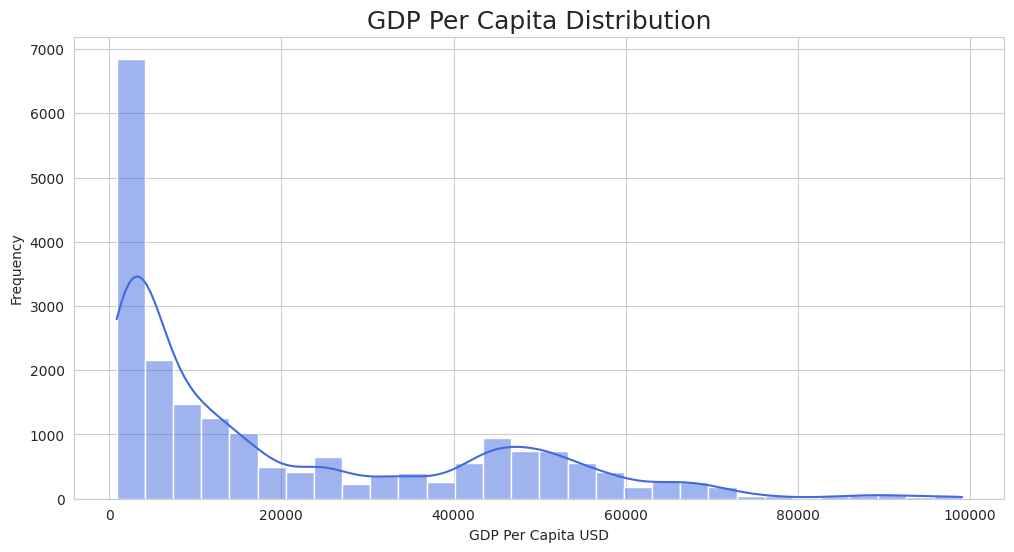

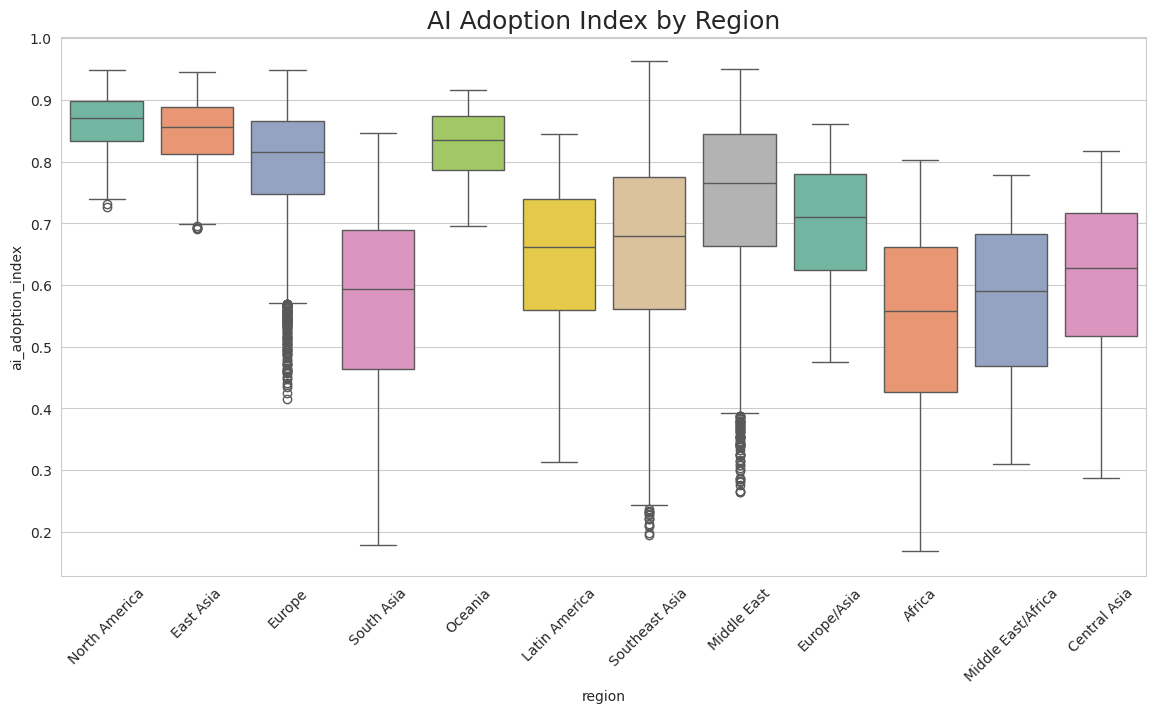

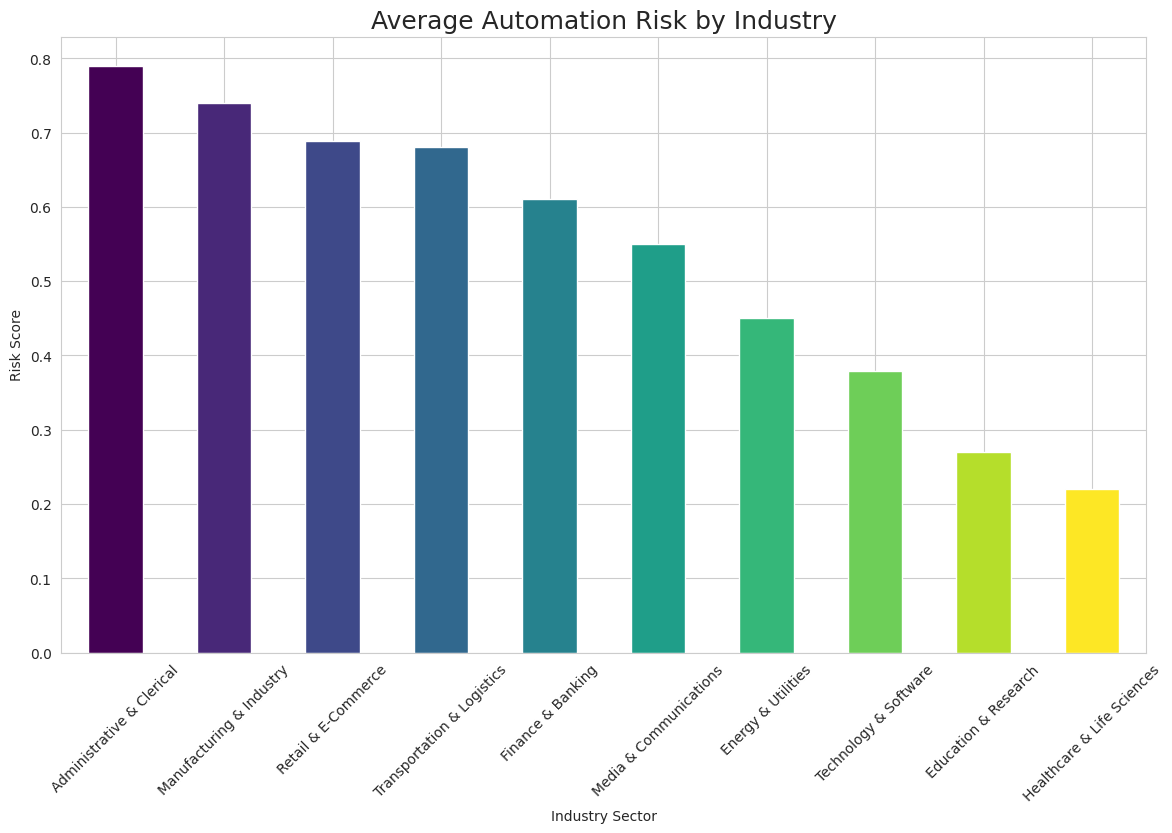

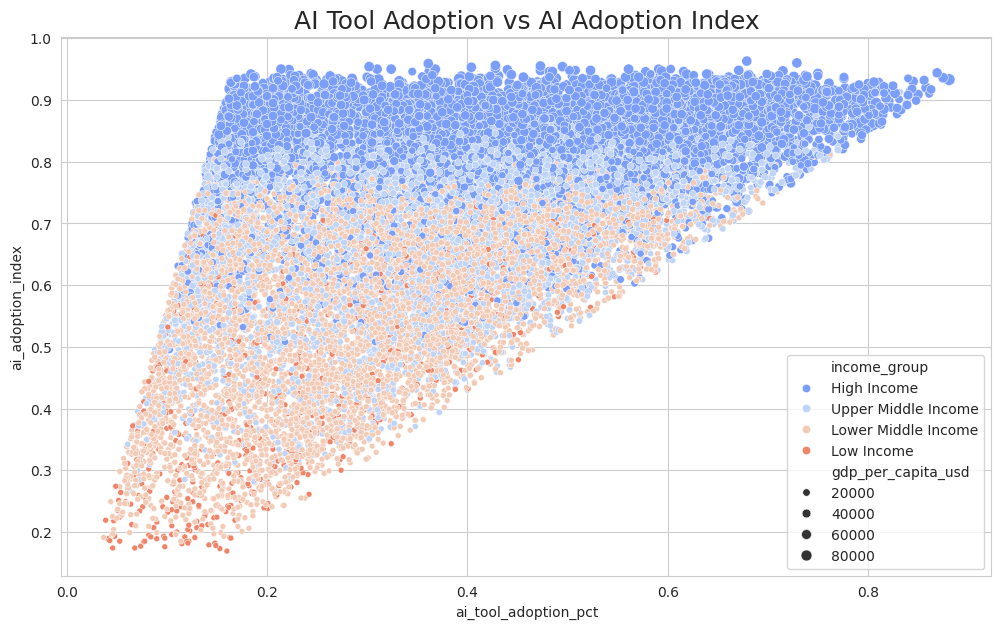

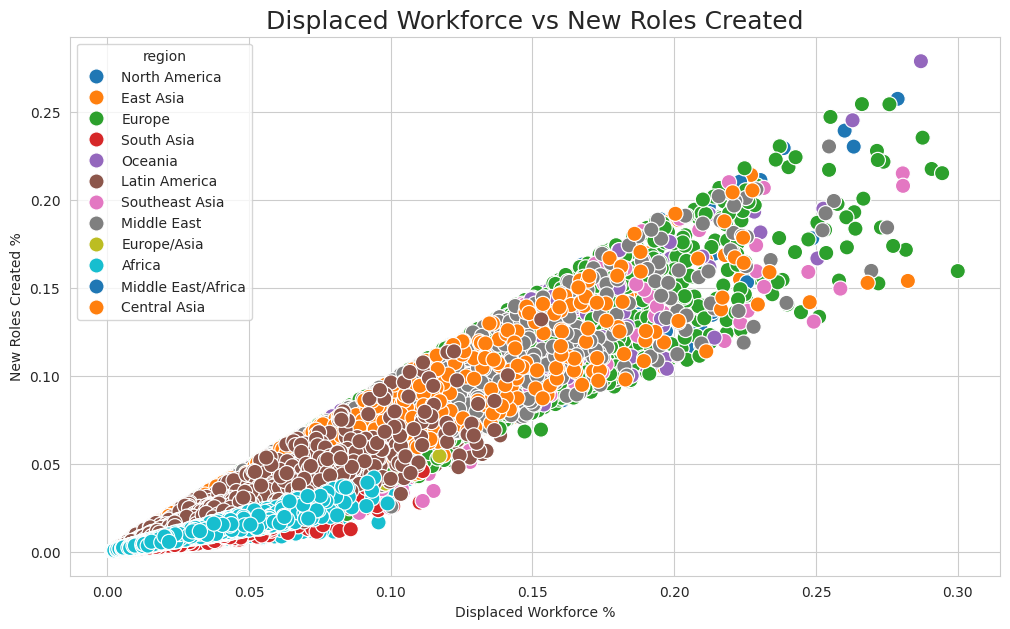

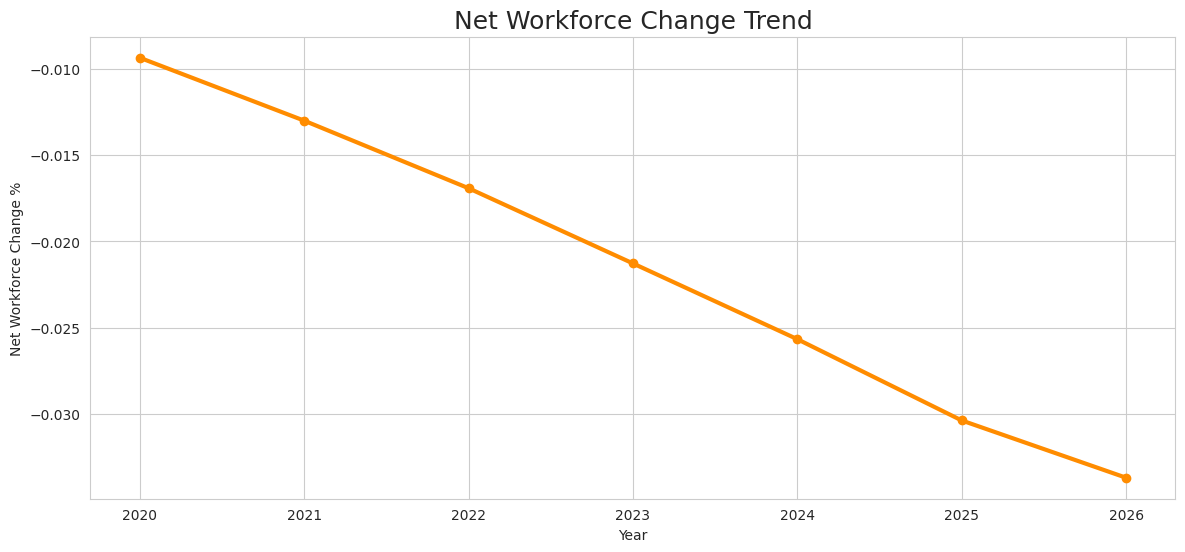

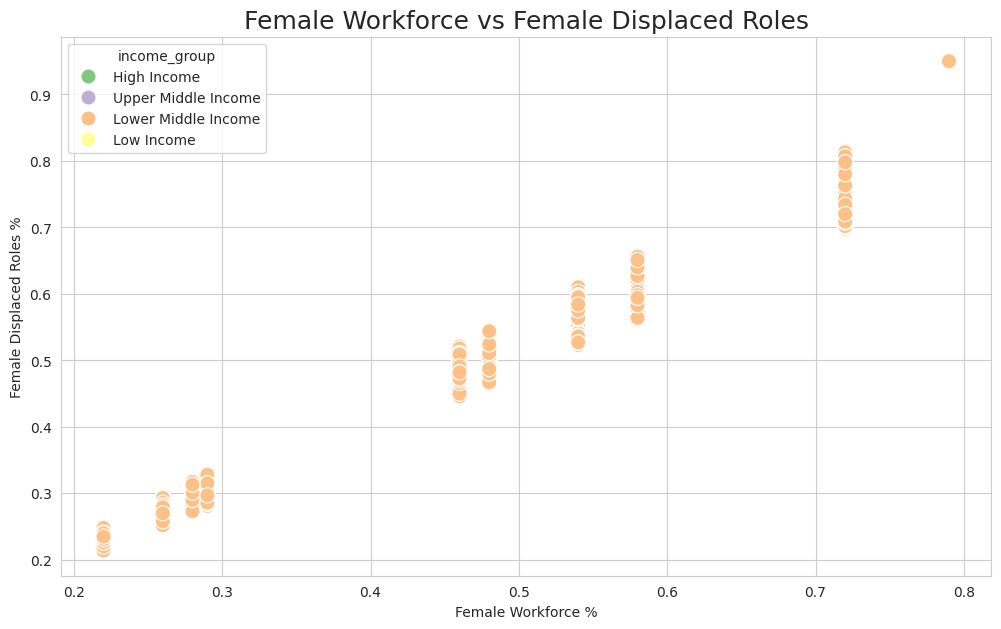

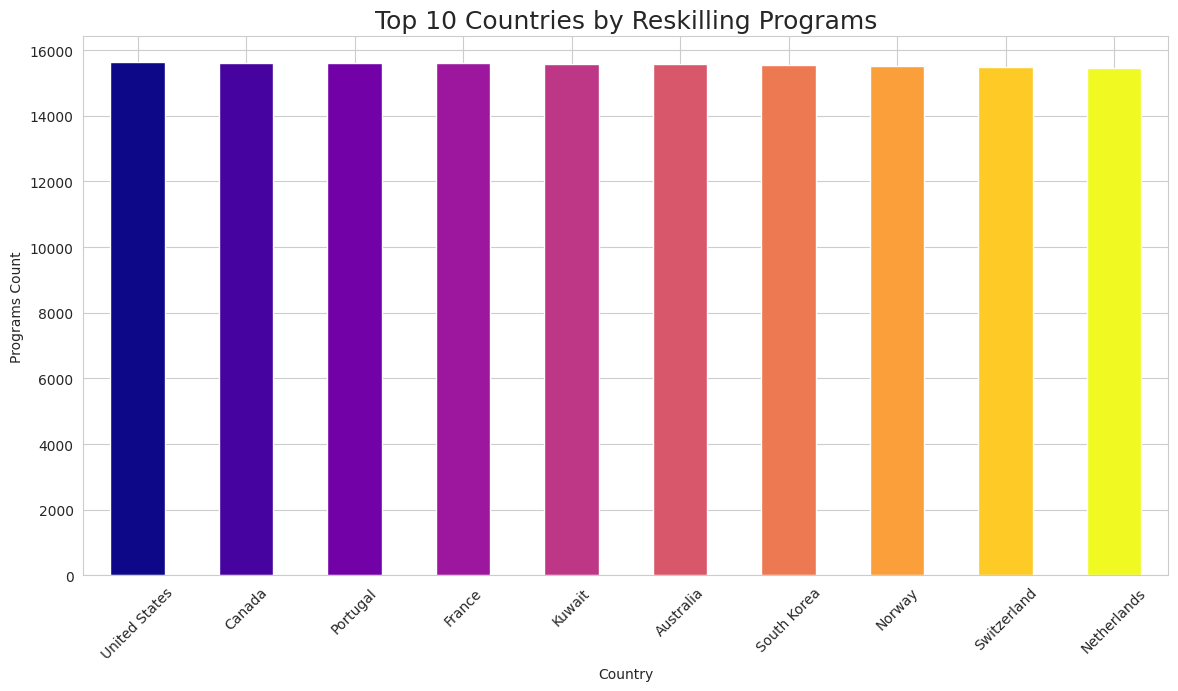

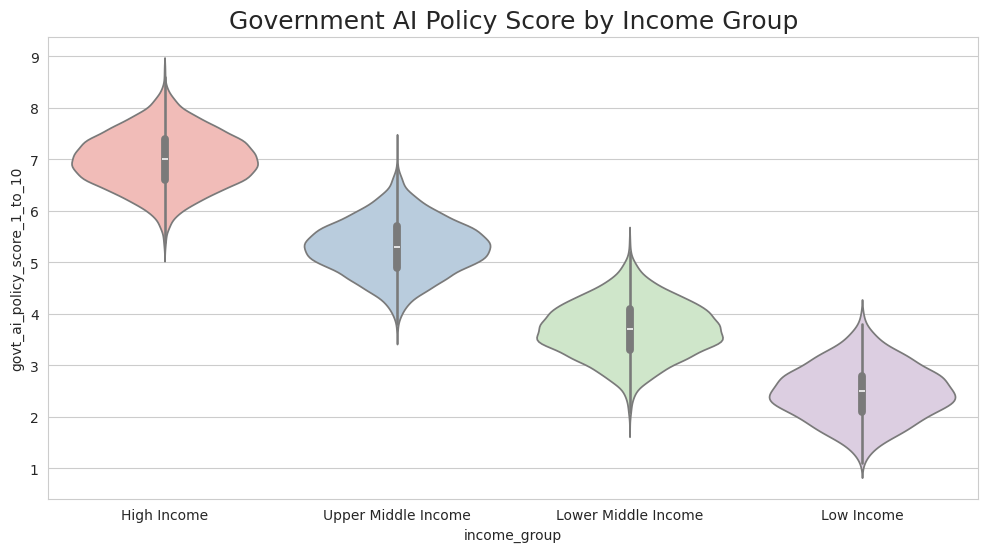

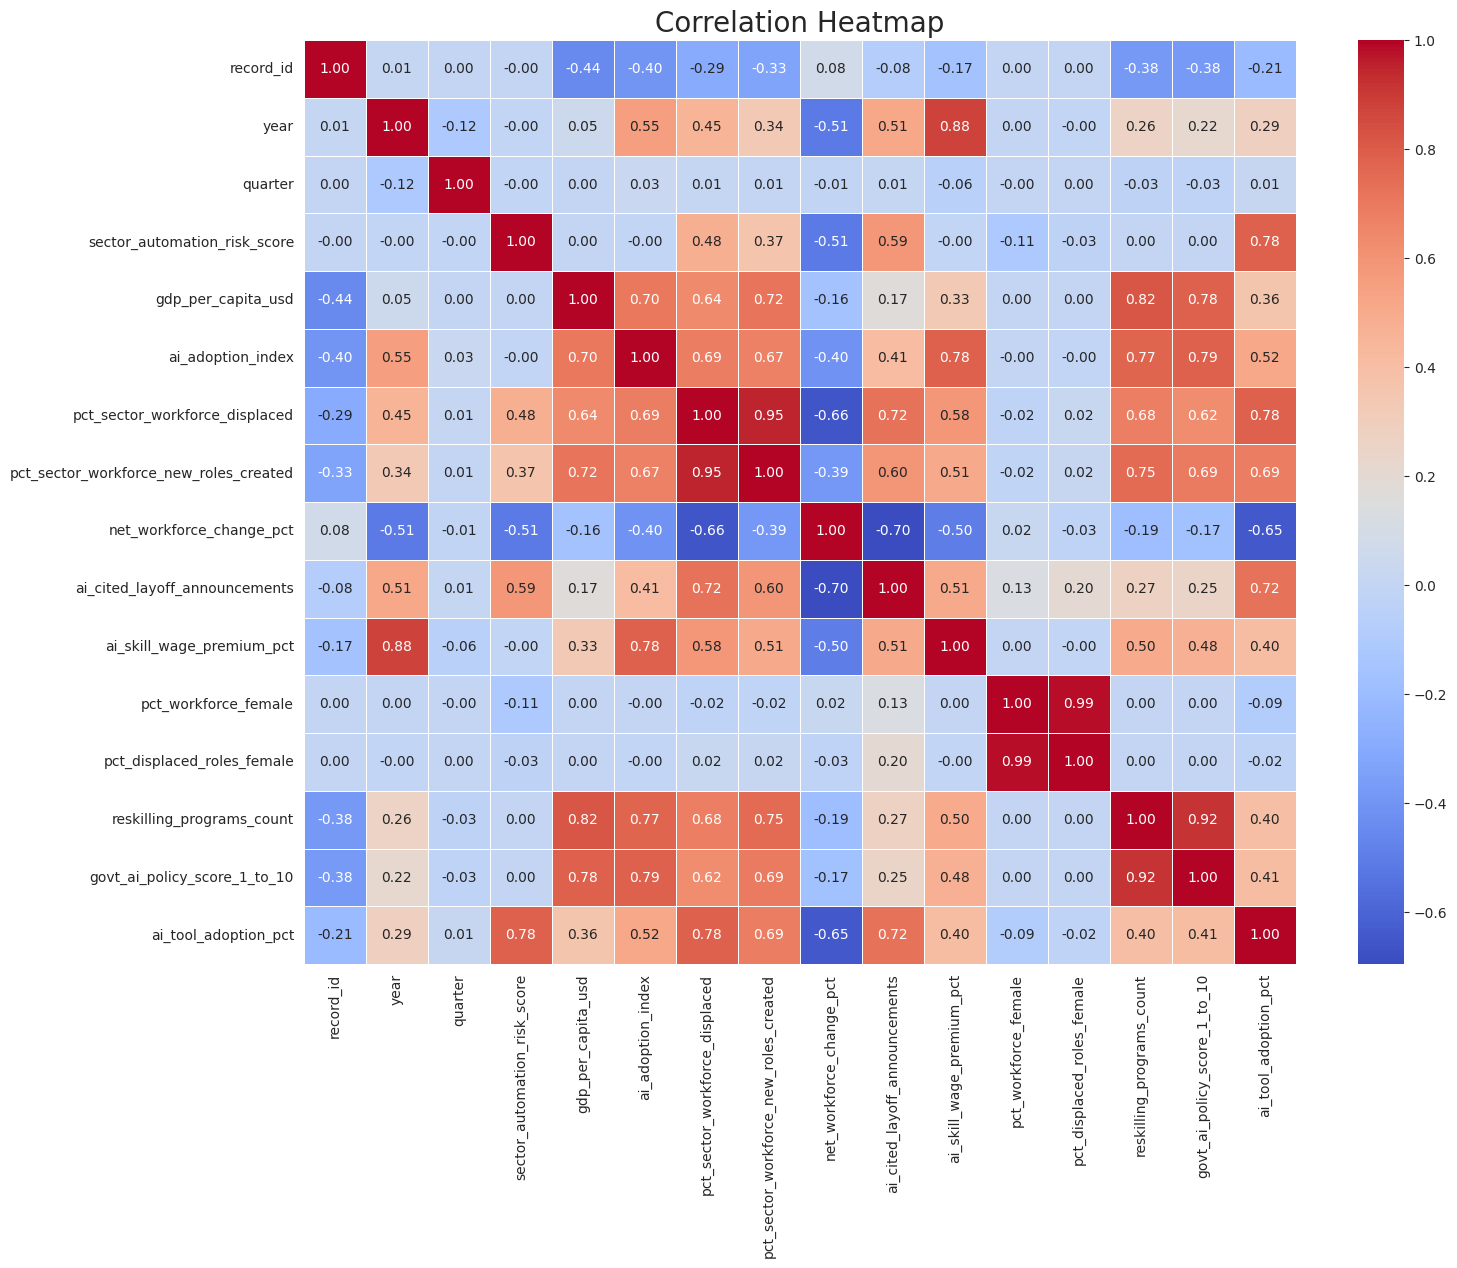

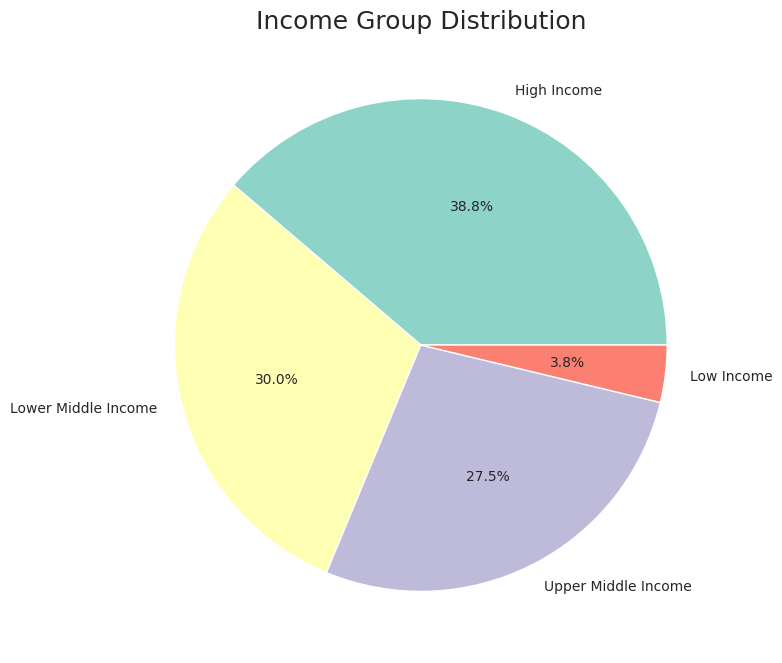

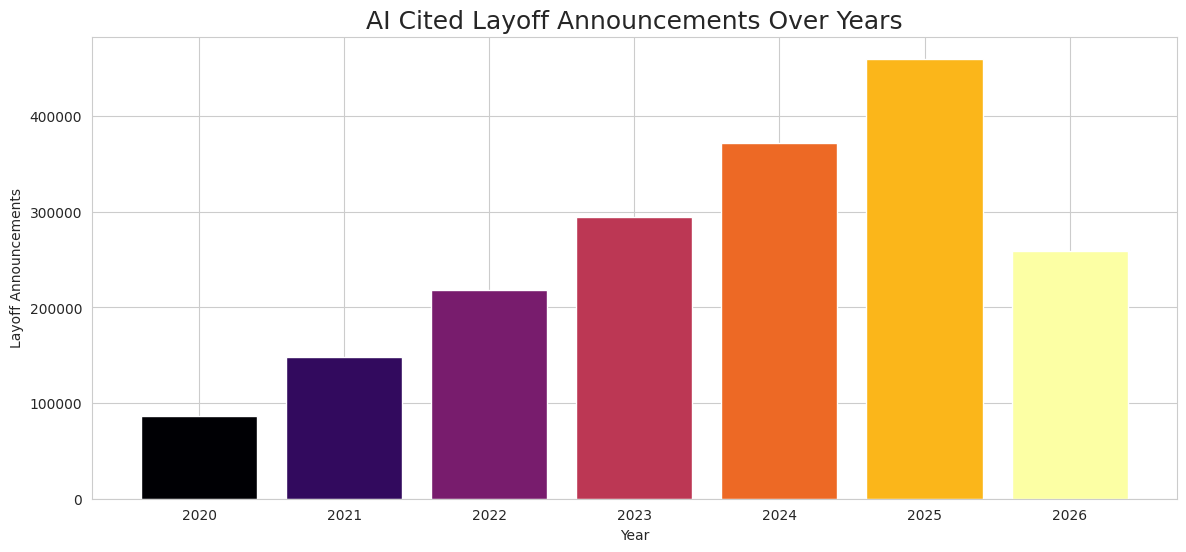

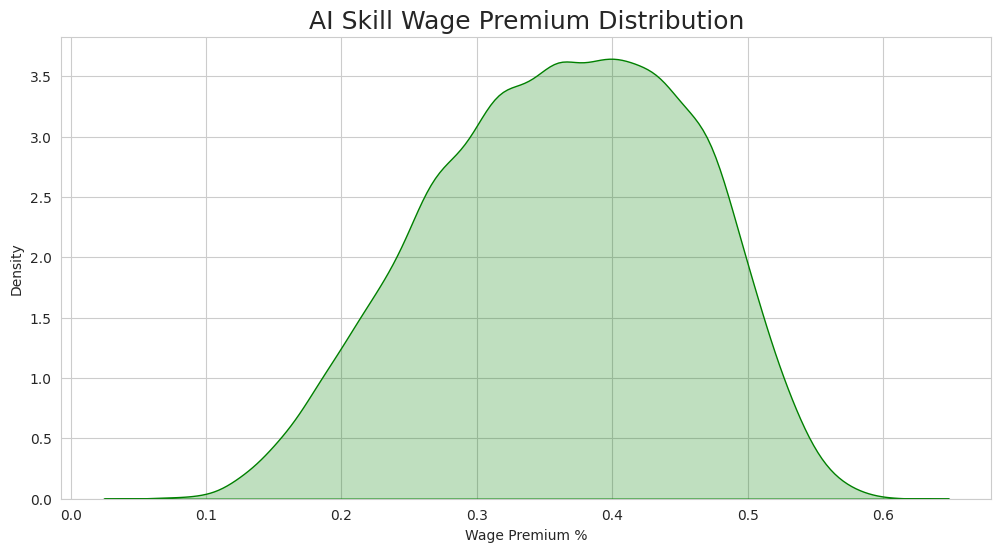

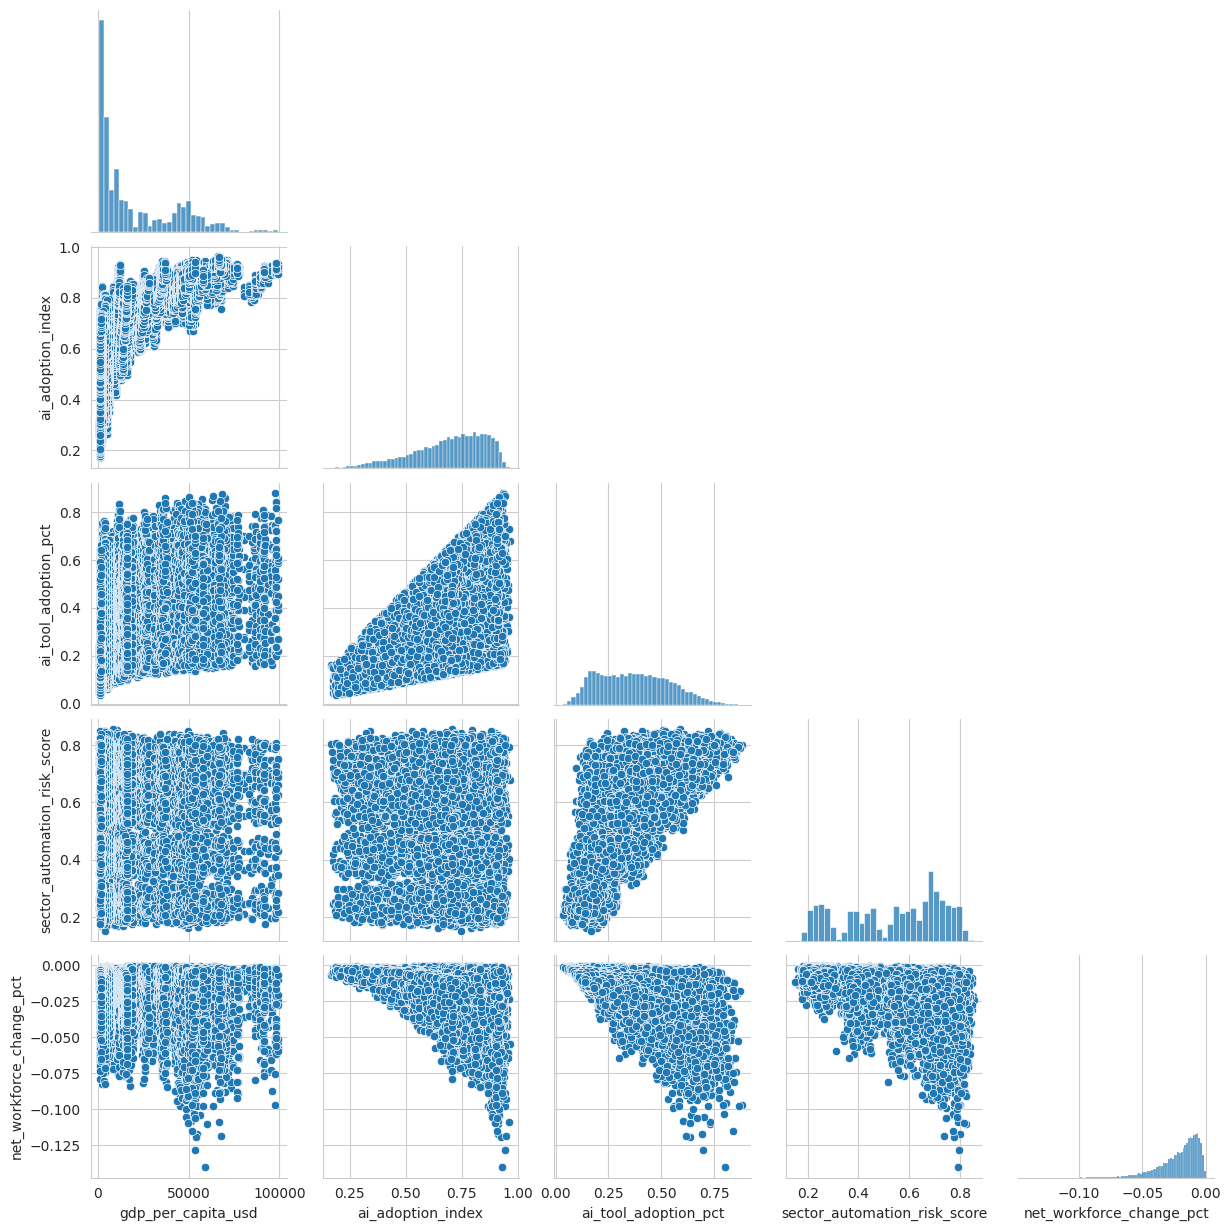


All Visualizations Generated Successfully!


In [14]:
# Fill numeric missing values with median
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical missing values
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# --------------------------------------------
# SET STYLE
# --------------------------------------------
sns.set_style("whitegrid")

# ============================================
# 1. GDP PER CAPITA DISTRIBUTION
# ============================================
plt.figure(figsize=(12,6))

sns.histplot(
    df['gdp_per_capita_usd'],
    bins=30,
    kde=True,
    color='royalblue'
)

plt.title("GDP Per Capita Distribution", fontsize=18)
plt.xlabel("GDP Per Capita USD")
plt.ylabel("Frequency")
plt.show()

# ============================================
# 2. AI ADOPTION INDEX BY REGION
# ============================================
plt.figure(figsize=(14,7))

sns.boxplot(
    x='region',
    y='ai_adoption_index',
    data=df,
    palette='Set2'
)

plt.title("AI Adoption Index by Region", fontsize=18)
plt.xticks(rotation=45)
plt.show()

# ============================================
# 3. AUTOMATION RISK BY INDUSTRY
# ============================================
industry_risk = df.groupby('industry_sector')[
    'sector_automation_risk_score'
].mean().sort_values(ascending=False)

plt.figure(figsize=(14,8))

industry_risk.plot(
    kind='bar',
    color=plt.cm.viridis(np.linspace(0,1,len(industry_risk)))
)

plt.title("Average Automation Risk by Industry", fontsize=18)
plt.xlabel("Industry Sector")
plt.ylabel("Risk Score")
plt.xticks(rotation=45)
plt.show()

# ============================================
# 4. AI TOOL ADOPTION VS AI ADOPTION INDEX
# ============================================
plt.figure(figsize=(12,7))

sns.scatterplot(
    x='ai_tool_adoption_pct',
    y='ai_adoption_index',
    hue='income_group',
    size='gdp_per_capita_usd',
    palette='coolwarm',
    data=df
)

plt.title("AI Tool Adoption vs AI Adoption Index", fontsize=18)
plt.show()

# ============================================
# 5. WORKFORCE DISPLACEMENT VS NEW ROLES
# ============================================
plt.figure(figsize=(12,7))

sns.scatterplot(
    x='pct_sector_workforce_displaced',
    y='pct_sector_workforce_new_roles_created',
    hue='region',
    palette='tab10',
    data=df,
    s=120
)

plt.title("Displaced Workforce vs New Roles Created", fontsize=18)
plt.xlabel("Displaced Workforce %")
plt.ylabel("New Roles Created %")
plt.show()

# ============================================
# 6. NET WORKFORCE CHANGE TREND OVER YEARS
# ============================================
yearly_trend = df.groupby('year')[
    'net_workforce_change_pct'
].mean()

plt.figure(figsize=(14,6))

plt.plot(
    yearly_trend.index,
    yearly_trend.values,
    marker='o',
    linewidth=3,
    color='darkorange'
)

plt.title("Net Workforce Change Trend", fontsize=18)
plt.xlabel("Year")
plt.ylabel("Net Workforce Change %")
plt.grid(True)
plt.show()

# ============================================
# 7. FEMALE WORKFORCE ANALYSIS
# ============================================
plt.figure(figsize=(12,7))

sns.scatterplot(
    x='pct_workforce_female',
    y='pct_displaced_roles_female',
    hue='income_group',
    palette='Accent',
    s=120,
    data=df
)

plt.title("Female Workforce vs Female Displaced Roles", fontsize=18)
plt.xlabel("Female Workforce %")
plt.ylabel("Female Displaced Roles %")
plt.show()

# ============================================
# 8. RESKILLING PROGRAMS BY COUNTRY
# ============================================
top_countries = (
    df.groupby('country')['reskilling_programs_count']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(14,7))

top_countries.plot(
    kind='bar',
    color=plt.cm.plasma(np.linspace(0,1,len(top_countries)))
)

plt.title("Top 10 Countries by Reskilling Programs", fontsize=18)
plt.xlabel("Country")
plt.ylabel("Programs Count")
plt.xticks(rotation=45)
plt.show()

# ============================================
# 9. GOVERNMENT AI POLICY SCORE
# ============================================
plt.figure(figsize=(12,6))

sns.violinplot(
    x='income_group',
    y='govt_ai_policy_score_1_to_10',
    data=df,
    palette='Pastel1'
)

plt.title("Government AI Policy Score by Income Group", fontsize=18)
plt.show()

# ============================================
# 10. CORRELATION HEATMAP
# ============================================
plt.figure(figsize=(16,12))

corr = df[numeric_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5,
    fmt='.2f'
)

plt.title("Correlation Heatmap", fontsize=20)
plt.show()

# ============================================
# 11. INTERACTIVE PLOTLY VISUALIZATION
# ============================================
fig = px.scatter(
    df,
    x='gdp_per_capita_usd',
    y='ai_adoption_index',
    color='region',
    size='ai_tool_adoption_pct',
    hover_name='country',
    title='Interactive AI Adoption Analysis',
    color_discrete_sequence=px.colors.qualitative.Bold
)

fig.show()

# ============================================
# 12. SUNBURST CHART
# ============================================
fig = px.sunburst(
    df,
    path=['region', 'country', 'industry_sector'],
    values='ai_tool_adoption_pct',
    color='ai_adoption_index',
    color_continuous_scale='RdYlGn',
    title='AI Adoption Hierarchy'
)

fig.show()

# ============================================
# 13. PIE CHART - INCOME GROUP DISTRIBUTION
# ============================================
income_counts = df['income_group'].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    income_counts,
    labels=income_counts.index,
    autopct='%1.1f%%',
    colors=sns.color_palette('Set3')
)

plt.title("Income Group Distribution", fontsize=18)
plt.show()

# ============================================
# 14. AI LAYOFF ANNOUNCEMENTS TREND
# ============================================
layoff_trend = df.groupby('year')[
    'ai_cited_layoff_announcements'
].sum()

plt.figure(figsize=(14,6))

plt.bar(
    layoff_trend.index,
    layoff_trend.values,
    color=plt.cm.inferno(np.linspace(0,1,len(layoff_trend)))
)

plt.title("AI Cited Layoff Announcements Over Years", fontsize=18)
plt.xlabel("Year")
plt.ylabel("Layoff Announcements")
plt.show()

# ============================================
# 15. KDE PLOT
# ============================================
plt.figure(figsize=(12,6))

sns.kdeplot(
    df['ai_skill_wage_premium_pct'],
    fill=True,
    color='green'
)

plt.title("AI Skill Wage Premium Distribution", fontsize=18)
plt.xlabel("Wage Premium %")
plt.show()

# ============================================
# 16. PAIRPLOT
# ============================================
selected_cols = [
    'gdp_per_capita_usd',
    'ai_adoption_index',
    'ai_tool_adoption_pct',
    'sector_automation_risk_score',
    'net_workforce_change_pct'
]

sns.pairplot(
    df[selected_cols],
    corner=True,
    palette='husl'
)

plt.show()

# ============================================
# COMPLETED
# ============================================
print("\nAll Visualizations Generated Successfully!")

## Feature Engineering


Checking Target Source Column...

Median Value:
-0.0164

Target Distribution:
target
0    10450
1    10350
Name: count, dtype: int64


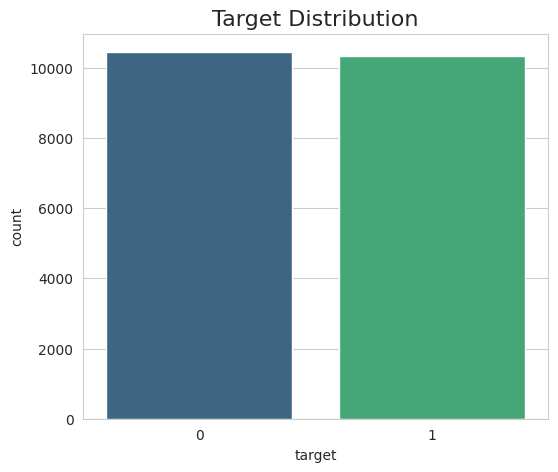


Dropped Columns:
['record_id', 'data_source_notes', 'net_workforce_change_pct']

Categorical Columns:
Index(['country', 'iso3_code', 'region', 'income_group', 'quarter_label',
       'industry_sector'],
      dtype='object')

Label Encoding Completed!

Feature Shape: (20800, 20)
Target Shape: (20800,)

Training Shape: (16640, 20)
Testing Shape: (4160, 20)


MODEL: Logistic Regression

Accuracy: 0.9808

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      2090
           1       0.97      0.99      0.98      2070

    accuracy                           0.98      4160
   macro avg       0.98      0.98      0.98      4160
weighted avg       0.98      0.98      0.98      4160



<Figure size 1200x800 with 0 Axes>

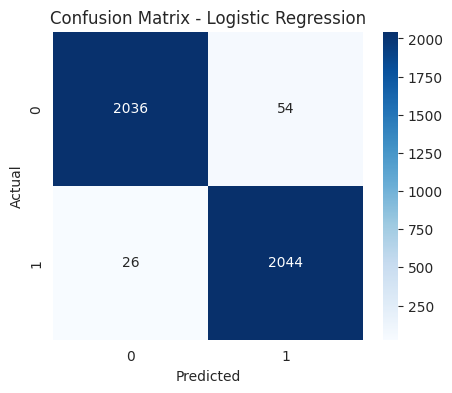



MODEL: Decision Tree

Accuracy: 0.8750

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.90      0.88      2090
           1       0.89      0.85      0.87      2070

    accuracy                           0.88      4160
   macro avg       0.88      0.87      0.87      4160
weighted avg       0.88      0.88      0.87      4160



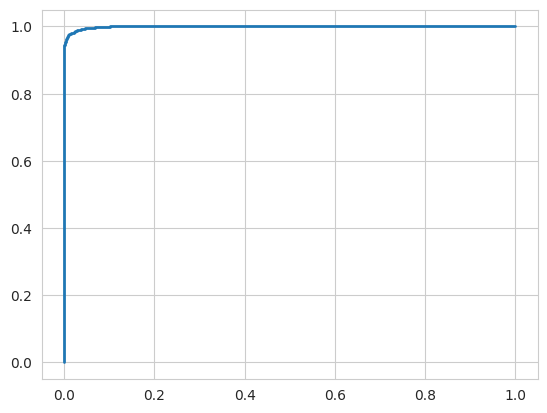

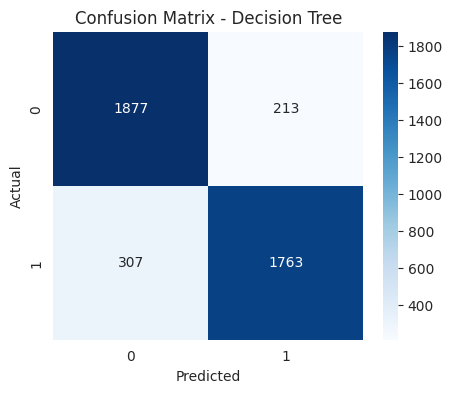



MODEL: Random Forest

Accuracy: 0.9332

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.94      0.93      2090
           1       0.94      0.92      0.93      2070

    accuracy                           0.93      4160
   macro avg       0.93      0.93      0.93      4160
weighted avg       0.93      0.93      0.93      4160



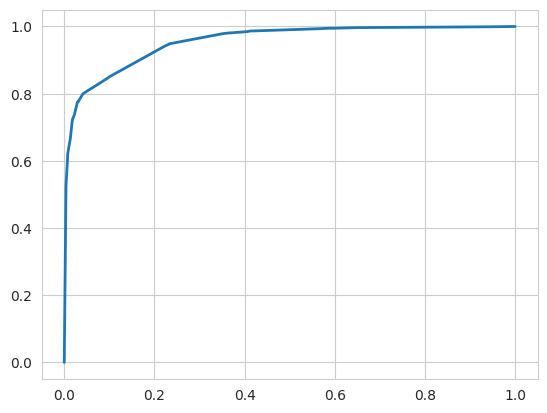

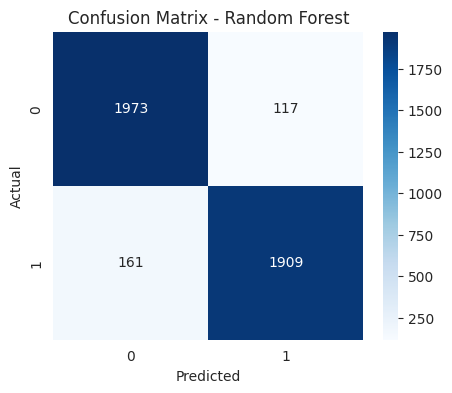



MODEL: Gradient Boosting

Accuracy: 0.9632

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.97      0.96      2090
           1       0.97      0.96      0.96      2070

    accuracy                           0.96      4160
   macro avg       0.96      0.96      0.96      4160
weighted avg       0.96      0.96      0.96      4160



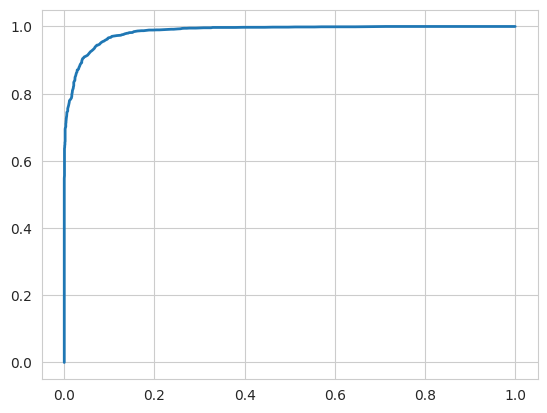

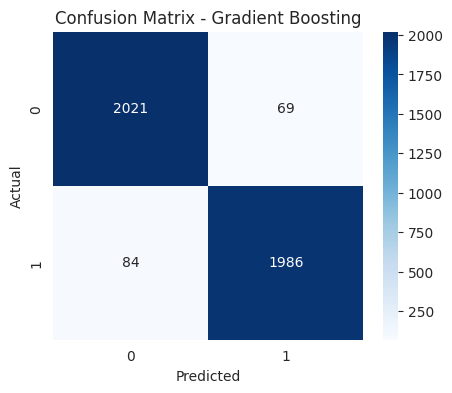



MODEL: SVM

Accuracy: 0.9454

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.94      0.95      2090
           1       0.94      0.95      0.95      2070

    accuracy                           0.95      4160
   macro avg       0.95      0.95      0.95      4160
weighted avg       0.95      0.95      0.95      4160



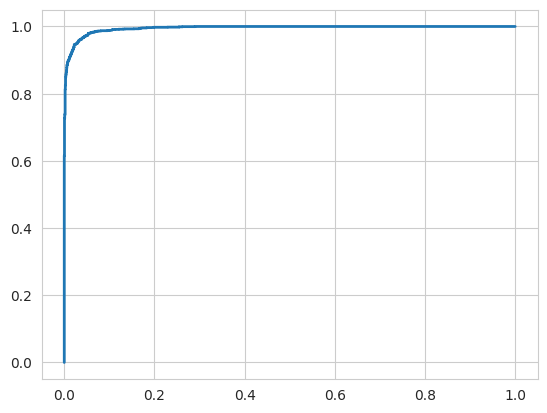

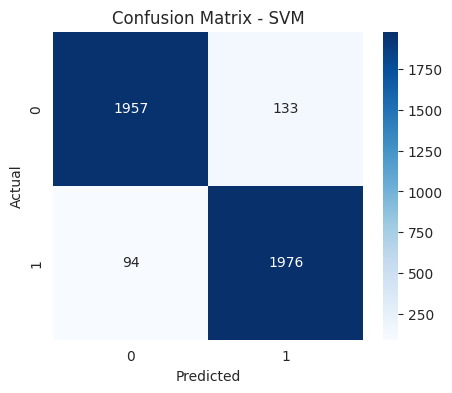



MODEL: KNN

Accuracy: 0.8430

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.86      0.85      2090
           1       0.86      0.82      0.84      2070

    accuracy                           0.84      4160
   macro avg       0.84      0.84      0.84      4160
weighted avg       0.84      0.84      0.84      4160



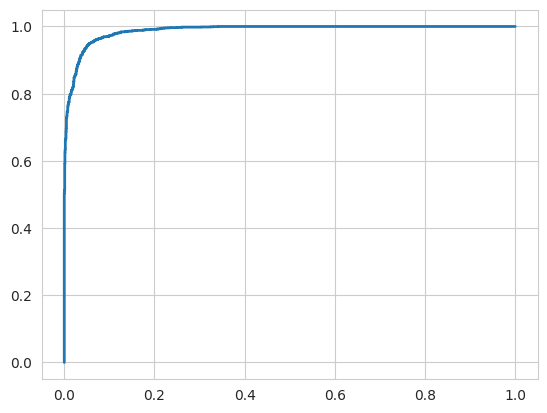

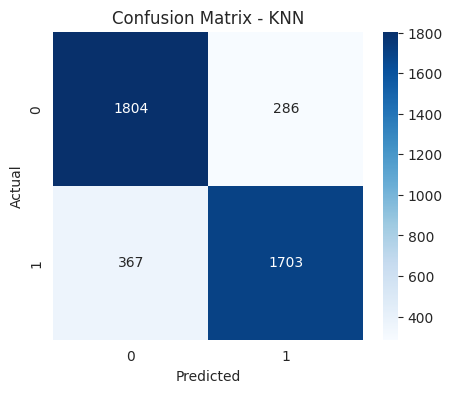

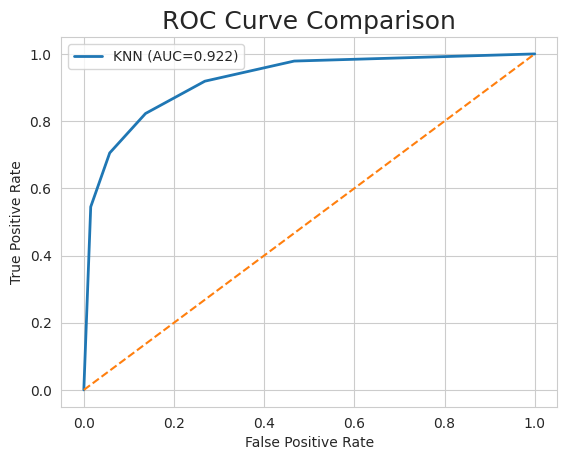



FINAL MODEL RESULTS
                 Model  Accuracy   ROC_AUC
0  Logistic Regression  0.980769  0.998963
3    Gradient Boosting  0.963221  0.994747
4                  SVM  0.945433  0.988001
2        Random Forest  0.933173  0.985310
1        Decision Tree  0.875000  0.954974
5                  KNN  0.843029  0.921515


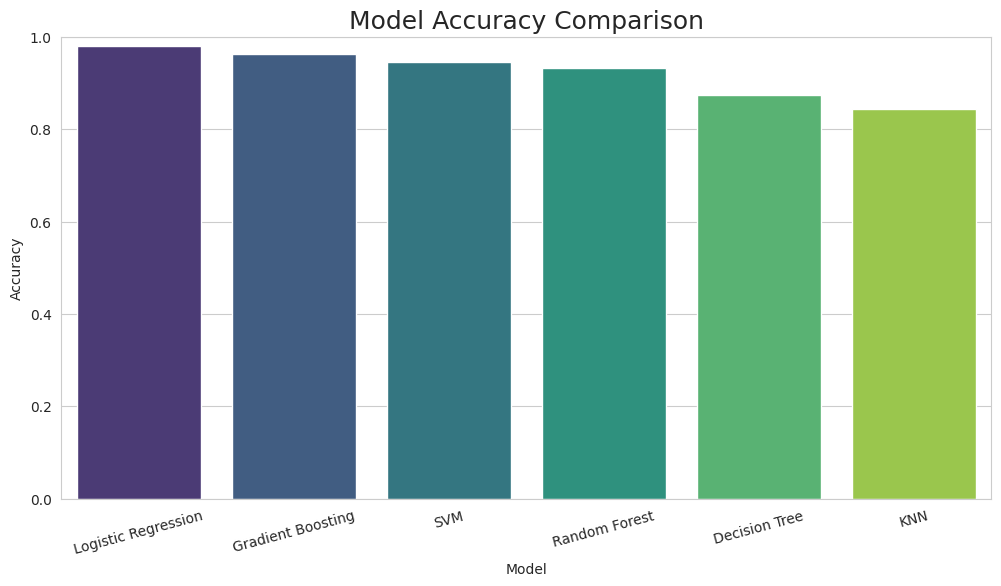

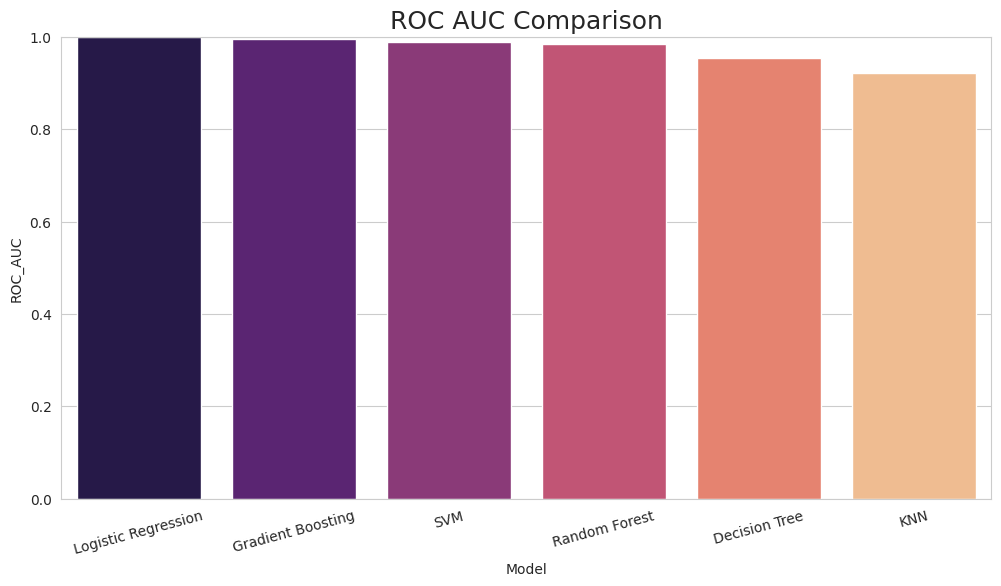


Top Feature Importance:

                                   Feature  Importance
11          pct_sector_workforce_displaced    0.212636
13           ai_cited_layoff_announcements    0.172964
12  pct_sector_workforce_new_roles_created    0.106308
19                    ai_tool_adoption_pct    0.083392
8             sector_automation_risk_score    0.067537
6                            quarter_label    0.045052
14               ai_skill_wage_premium_pct    0.043811
9                       gdp_per_capita_usd    0.040892
10                       ai_adoption_index    0.036519
4                                     year    0.033723
17               reskilling_programs_count    0.032190
18            govt_ai_policy_score_1_to_10    0.025641
16              pct_displaced_roles_female    0.021947
0                                  country    0.013575
3                             income_group    0.013298


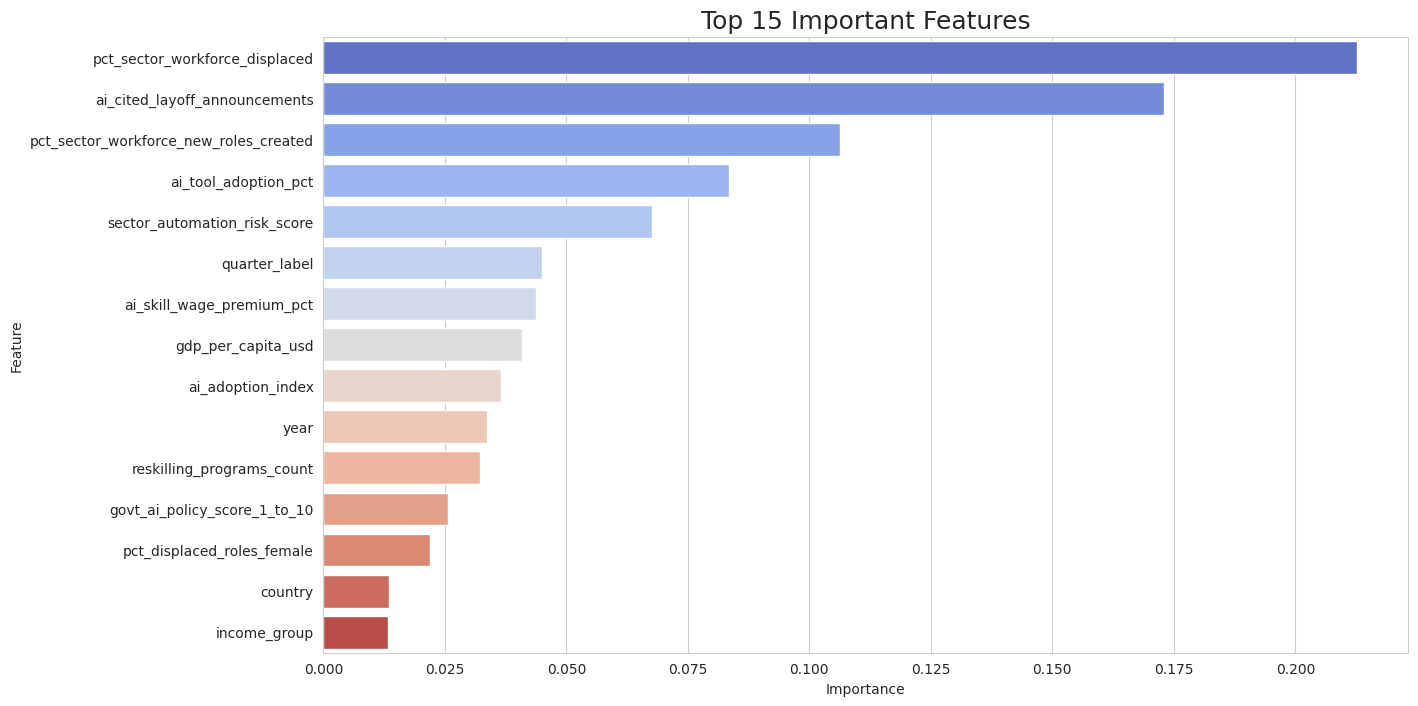



BEST MODEL
Best Model : Logistic Regression
Accuracy   : 0.9808
ROC AUC    : 0.9990

Machine Learning Pipeline Completed Successfully!


In [15]:
# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

df.columns = df.columns.str.strip()


print("\nChecking Target Source Column...")

if 'net_workforce_change_pct' not in df.columns:
    print("\nAvailable Columns:")
    print(df.columns.tolist())

    raise ValueError(
        "'net_workforce_change_pct' column NOT found.\n"
        "Please check your dataset column names."
    )

# ==========================================================
# HANDLE MISSING VALUES
# ==========================================================

# Numerical Columns
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Categorical Columns
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# ==========================================================
# CREATE TARGET VARIABLE
# ==========================================================

# Create target BEFORE dropping columns
median_value = df['net_workforce_change_pct'].median()

print("\nMedian Value:")
print(median_value)

df['target'] = np.where(
    df['net_workforce_change_pct'] > median_value,
    1,
    0
)

# ==========================================================
# TARGET DISTRIBUTION
# ==========================================================
print("\nTarget Distribution:")
print(df['target'].value_counts())

# ==========================================================
# TARGET VISUALIZATION
# ==========================================================
plt.figure(figsize=(6,5))

sns.countplot(
    x='target',
    data=df,
    palette='viridis'
)

plt.title("Target Distribution", fontsize=16)

plt.show()

# ==========================================================
# DROP LEAKAGE COLUMNS
# ==========================================================
drop_columns = [
    'record_id',
    'data_source_notes',
    'net_workforce_change_pct'
]

# Drop only existing columns
drop_columns = [col for col in drop_columns if col in df.columns]

df.drop(columns=drop_columns, inplace=True)

print("\nDropped Columns:")
print(drop_columns)

# ==========================================================
# LABEL ENCODING
# ==========================================================
label_encoders = {}

categorical_columns = df.select_dtypes(include='object').columns

print("\nCategorical Columns:")
print(categorical_columns)

for col in categorical_columns:

    le = LabelEncoder()

    df[col] = le.fit_transform(df[col])

    label_encoders[col] = le

print("\nLabel Encoding Completed!")

# ==========================================================
# FEATURES & TARGET
# ==========================================================
X = df.drop('target', axis=1)

y = df['target']

print("\nFeature Shape:", X.shape)
print("Target Shape:", y.shape)

# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

# ==========================================================
# FEATURE SCALING
# ==========================================================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# ==========================================================
# MODELS
# ==========================================================
models = {

    "Logistic Regression": LogisticRegression(),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=6,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "SVM": SVC(
        probability=True,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    )
}

# ==========================================================
# MODEL TRAINING
# ==========================================================
results = []

# ROC Curve Figure
plt.figure(figsize=(12,8))

for model_name, model in models.items():

    print("\n")
    print("="*70)
    print(f"MODEL: {model_name}")
    print("="*70)

    # ======================================================
    # TRAIN MODEL
    # ======================================================
    model.fit(X_train_scaled, y_train)

    # ======================================================
    # PREDICTION
    # ======================================================
    y_pred = model.predict(X_test_scaled)

    # ======================================================
    # ACCURACY
    # ======================================================
    accuracy = accuracy_score(y_test, y_pred)

    print(f"\nAccuracy: {accuracy:.4f}")

    # ======================================================
    # CLASSIFICATION REPORT
    # ======================================================
    print("\nClassification Report:\n")

    print(classification_report(y_test, y_pred))

    # ======================================================
    # CONFUSION MATRIX
    # ======================================================
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(f"Confusion Matrix - {model_name}")

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

    # ======================================================
    # ROC CURVE
    # ======================================================
    y_prob = model.predict_proba(X_test_scaled)[:,1]

    fpr, tpr, thresholds = roc_curve(y_test, y_prob)

    auc_score = roc_auc_score(y_test, y_prob)

    # Save results
    results.append([
        model_name,
        accuracy,
        auc_score
    ])

    # Plot ROC
    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{model_name} (AUC={auc_score:.3f})"
    )

# ==========================================================
# FINAL ROC CURVE
# ==========================================================
plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison", fontsize=18)

plt.legend()

plt.grid(True)

plt.show()

# ==========================================================
# RESULTS TABLE
# ==========================================================
results_df = pd.DataFrame(
    results,
    columns=['Model', 'Accuracy', 'ROC_AUC']
)

results_df = results_df.sort_values(
    by='Accuracy',
    ascending=False
)

print("\n")
print("="*70)
print("FINAL MODEL RESULTS")
print("="*70)

print(results_df)

# ==========================================================
# ACCURACY BARPLOT
# ==========================================================
plt.figure(figsize=(12,6))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=results_df,
    palette='viridis'
)

plt.title("Model Accuracy Comparison", fontsize=18)

plt.xticks(rotation=15)

plt.ylim(0,1)

plt.show()

# ==========================================================
# ROC AUC BARPLOT
# ==========================================================
plt.figure(figsize=(12,6))

sns.barplot(
    x='Model',
    y='ROC_AUC',
    data=results_df,
    palette='magma'
)

plt.title("ROC AUC Comparison", fontsize=18)

plt.xticks(rotation=15)

plt.ylim(0,1)

plt.show()

# ==========================================================
# FEATURE IMPORTANCE
# ==========================================================
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train_scaled, y_train)

importance_df = pd.DataFrame({

    'Feature': X.columns,

    'Importance': rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print("\nTop Feature Importance:\n")
print(importance_df.head(15))

# ==========================================================
# FEATURE IMPORTANCE PLOT
# ==========================================================
plt.figure(figsize=(14,8))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df.head(15),
    palette='coolwarm'
)

plt.title("Top 15 Important Features", fontsize=18)

plt.show()

# ==========================================================
# BEST MODEL
# ==========================================================
best_model = results_df.iloc[0]

print("\n")
print("="*70)
print("BEST MODEL")
print("="*70)

print(f"Best Model : {best_model['Model']}")
print(f"Accuracy   : {best_model['Accuracy']:.4f}")
print(f"ROC AUC    : {best_model['ROC_AUC']:.4f}")

print("\nMachine Learning Pipeline Completed Successfully!")

## Thank you...pls upvote!!!!!!!!!!!!!